# Preparation

In [1]:
!pip install basicsr
!pip install super-image
!pip install torch
!pip install torchvision
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.8 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214817 sha256=54e04f1566748272fd629dab1e2e4f3bb1f0e4e856e2019813c5e5bbf3debf80
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
Successfully built basicsr
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 5.9 MB/s eta 0:00:00


In [2]:
import requests
from PIL import Image
from io import BytesIO
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np

In [3]:
import glob
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
device

'cuda'

In [6]:
#DATA_PATH = "/gdrive/MyDrive/Super_Resolution/Data/Test_images_2023"
#DATA_PATH = "/gdrive/MyDrive/SR_seeds/Test_images_2023"
DATA_PATH = "/gdrive/MyDrive/SR_seeds/Grains_(Pasynkov)"

In [ ]:
all_orig_imgs = []
all_lr_imgs = []
for i in range(1, 2651):
  img = Image.open(DATA_PATH + f"/grain_{i}.png").convert("RGB")

  all_orig_imgs.append(img)

  w, h = img.size

  lr_img = img.resize((int(w*1), int(h*1)))
  all_lr_imgs.append(lr_img)

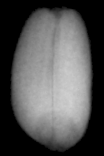

In [ ]:
all_orig_imgs[6]

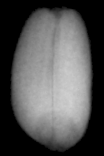

In [ ]:
all_lr_imgs[6]

In [ ]:
all_sr_imgs = []

# SRCNN

In [7]:
state_dict = torch.load('/gdrive/MyDrive/SR_seeds/srcnn_x4.pth')

for k, v in state_dict.items():
    print(k, v.shape)

conv1.weight torch.Size([64, 1, 9, 9])
conv1.bias torch.Size([64])
conv2.weight torch.Size([32, 64, 5, 5])
conv2.bias torch.Size([32])
conv3.weight torch.Size([1, 32, 5, 5])
conv3.bias torch.Size([1])


In [8]:
class SRCNN(nn.Module):
    def __init__(self, num_channels=1):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=9, padding=9 // 2)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=5 // 2)
        self.conv3 = nn.Conv2d(32, num_channels, kernel_size=5, padding=5 // 2)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

model = SRCNN().to(device)

model.load_state_dict(torch.load('/gdrive/MyDrive/SR_seeds/srcnn_x4.pth'))

transform = T.ToTensor()
to_pil = T.ToPILImage()

In [9]:
SAVE_PATH = "/gdrive/MyDrive/SR_seeds/SRCNN_(Pasynkov)/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
i = 2650
for img in all_lr_imgs:
    img = img.convert("L")
    i += 1

    w, h = img.size
    upscaled = img.resize((w*4, h*4))

    inp = transform(upscaled).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(inp)

    sr_img = to_pil(out.squeeze(0).cpu())
    all_sr_imgs.append(sr_img)

    filename = f"{str(i).zfill(4)}.png"  # 0001.png, 0002.png ...
    sr_img.save(os.path.join(SAVE_PATH, filename))

# Evaluation

In [10]:
LR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/LR/"
HR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/HR/"

In [11]:
all_lr_imgs = []
all_hr_imgs = []

In [12]:
for i in range(1, 8):
    lr_img = Image.open(os.path.join(LR_PATH, f"lr_img_{i}.png")).convert("RGB")
    hr_img = Image.open(os.path.join(HR_PATH, f"hr_img_{i}.png")).convert("RGB")

    all_lr_imgs.append(lr_img)
    all_hr_imgs.append(hr_img)

In [13]:
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np

psnr_list = []
ssim_list = []

In [14]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


def compute_ssim(sr, hr):
    sr = sr.permute(1, 2, 0).cpu().numpy()
    hr = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [15]:
sr_results = []

In [16]:
def match_size(sr, hr):
    """
    Приводит HR к размеру SR (или наоборот) через bilinear resize
    """
    sr_h, sr_w = sr.shape[-2], sr.shape[-1]
    hr = F.interpolate(hr.unsqueeze(0), size=(sr_h, sr_w), mode="bilinear", align_corners=False)
    return hr.squeeze(0)

In [17]:
for i, (lr_img, hr_img) in enumerate(zip(all_lr_imgs, all_hr_imgs)):

    # ===== SR inference =====
    lr_gray = lr_img.convert("L")

    w, h = lr_gray.size
    upscaled = lr_gray.resize((w*4, h*4))

    inp = transform(upscaled).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(inp)

    sr_tensor = out.squeeze(0).cpu().clamp(0, 1)

    sr_img = to_pil(sr_tensor)

    sr_results.append(sr_img)

    # ===== HR tensor =====
    hr_tensor = T.ToTensor()(hr_img.convert("L"))

    # ===== ALIGN SIZE (КРИТИЧНО) =====
    if hr_tensor.shape != sr_tensor.shape:
        hr_tensor = match_size(sr_tensor, hr_tensor)

    # ===== METRICS =====
    psnr_val = compute_psnr(sr_tensor, hr_tensor)
    ssim_val = compute_ssim(sr_tensor, hr_tensor)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    print(f"[{i+1}] PSNR: {psnr_val:.3f} | SSIM: {ssim_val:.4f}")


[1] PSNR: 36.564 | SSIM: 0.8836
[2] PSNR: 34.986 | SSIM: 0.8508
[3] PSNR: 36.860 | SSIM: 0.8755
[4] PSNR: 35.227 | SSIM: 0.8420
[5] PSNR: 32.654 | SSIM: 0.7611
[6] PSNR: 35.896 | SSIM: 0.8639
[7] PSNR: 34.921 | SSIM: 0.8444


In [18]:
print("\n========== FINAL ==========")
print(f"Mean PSNR: {np.mean(psnr_list):.3f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")


========== FINAL ==========
Mean PSNR: 35.301
Mean SSIM: 0.8459


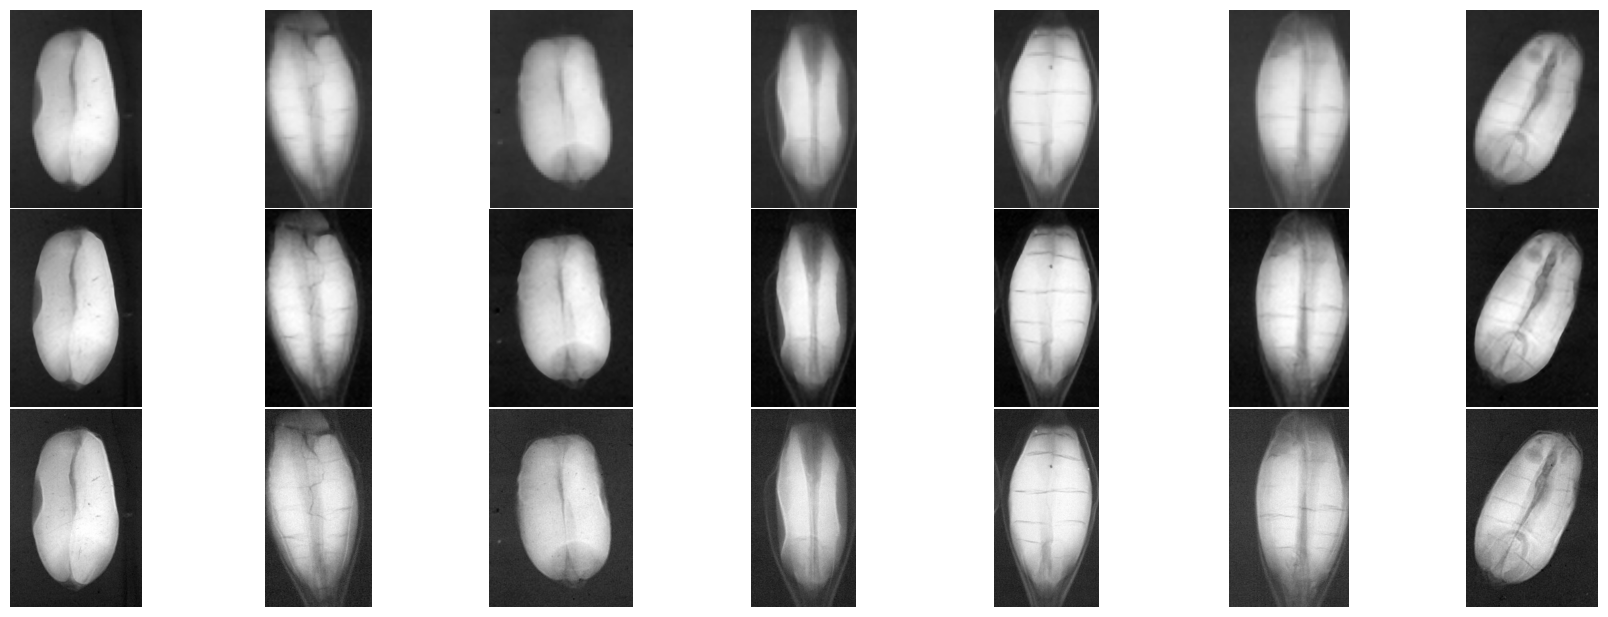

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 7, figsize=(18, 6))

plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(7):

    # ===== LR =====
    axes[0, i].imshow(all_lr_imgs[i])
    axes[0, i].axis("off")

    # ===== SR =====
    axes[1, i].imshow(sr_results[i].resize(all_hr_imgs[i].size), cmap="gray")
    axes[1, i].axis("off")

    # ===== HR =====
    axes[2, i].imshow(all_hr_imgs[i])
    axes[2, i].axis("off")

plt.tight_layout(pad=0.1)
plt.show()
